In [9]:
from astropy import units as u
from astropy.constants import G, c, k_B, sigma_sb
import simple_disk as sd
from matplotlib import pyplot as plt
import disk_newton_solver as newton
import numpy as np
from disk_newton_solver import Tester
import pandas as pd
import seaborn as sns

System of equations:
Equation I

$\frac{k T_c}{\mu m_p} + \frac{4\sigma T_c^4}{3c\rho}-\left[\frac{\dot{M}\Omega^2f}{3\pi\alpha\rho}\right]^{2/3}=0$

$\frac{\partial f_I}{\partial T_c} = \frac{16\sigma T_c^3}{3c\rho} + \frac{k}{m_p\mu}$

$\frac{\partial f_I}{\partial \rho} = \frac{2(f\dot{M})^{2/3}\Omega^{4/3}}{3^{5/3}(\pi\alpha)^{2/3}\rho^{5/3}}-\frac{4T_c^4\sigma}{3c\rho^2}$

Equation II

$\rho^{2/3}(\kappa_0+\kappa_1\rho T_c^{-7/2})-\left[\frac{32\pi\sigma\Omega R^3}{9GM\dot{M}f}\right]T_c^4\left[\frac{3\pi\alpha}{\dot{M}f\Omega^2}\right]^{1/3}=0$

$\frac{\partial f_{II}}{\partial \rho} = \frac{5\kappa_1\rho+2T_c^{7/2}\kappa_0}{3T_c^{7/2}(\rho)^{1/3}}$

$\frac{\partial f_{II}}{\partial T_c} = \frac{-128\pi^{4/3}(T_cR)^{3}(\alpha\Omega)^{1/3}\sigma}{3^{5/3}GM(f\dot{M})^{4/3}}-\frac{7\kappa_1\rho^{5/3}}{2T_c^{9/2}}$

Definitions:

$f=1-\sqrt{\frac{R_*}{R}}$

$\Omega=\sqrt{\frac{GM}{R^3}}$




Full system of equations:



$1.\ \rho = \Sigma/H; $

$2.\ H = c_s R^{3/2}/(GM)^{1/2}; $

$3.\ c_s^2 = P/\rho; $

$4.\ P = \frac{\rho k T_c}{\mu m_p} + \frac{4\sigma T_c^4}{3c}; $

$5.\ \frac{4\sigma T_c^4}{3\tau} = \frac{3GM\dot{M}}{8\pi R^3} \left[ 1 - \left(\frac{R_*}{R}\right)^{1/2} \right]; $

$6.\ \tau = \Sigma (\kappa_0 + \kappa_1 \rho T_c^{-7/2}) $

$7.\ \nu\Sigma = \frac{\dot{M}}{3\pi} \left[ 1 - \left(\frac{R_*}{R}\right)^{1/2} \right]; $

$8.\ \nu = \alpha c_s H; $


In [10]:
def f(x):
    return (x-2)**(1/3)-1

def fprime(x):
    return 1/(3*(x-2)**(2/3))

xs = np.linspace(-1,10,100)

In [11]:
x0 = 4
xn = x0
guesses = [x0]
guess_line = [f(x0)]
for i in range(0,4):
    print(f"Iteration {i} | xn starts as: {xn}")
    print(f"next x: {xn} - {f(xn)/fprime(xn)}")

    xn = xn - f(xn)/fprime(xn)
    print(f"={xn}")
    guesses.append(xn)
    guess_line.append(f(xn))

Iteration 0 | xn starts as: 4
next x: 4 - 1.2377968440954015
=2.7622031559045985
Iteration 1 | xn starts as: 2.7622031559045985
next x: 2.7622031559045985 - -0.216626266410052
=2.9788294223146505
Iteration 2 | xn starts as: 2.9788294223146505
next x: 2.9788294223146505 - -0.0210197565847236
=2.999849178899374
Iteration 3 | xn starts as: 2.999849178899374
next x: 2.999849178899374 - -0.00015081351778277973
=2.9999999924171568


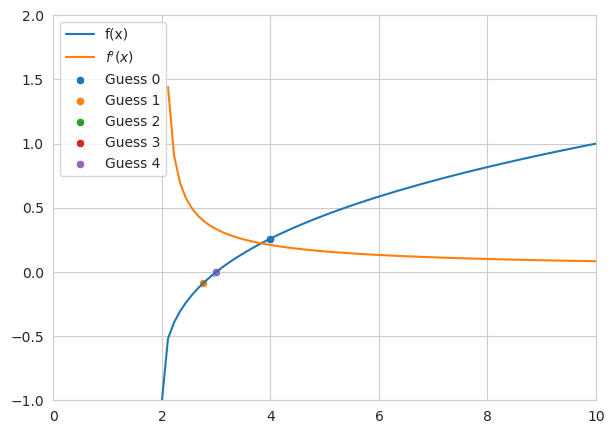

In [12]:
fig, ax = plt.subplots(figsize=(7,5))
sns.set_style("whitegrid")
sns.lineplot(ax=ax, x=xs, y=[f(x) for x in xs], label="f(x)")
sns.lineplot(ax=ax, x=xs, y=[fprime(x) for x in xs], label=r"$f'(x)$")
#sns.lineplot(ax=ax, x=xs, y=[-f(x)/fprime(x) for x in xs], label=r"$f/f'$")
for i in range(0, len(guesses)):
    sns.scatterplot(ax=ax, x=[guesses[i]], y=[guess_line[i]], label=f"Guess {i}")
ax.set_xlim(0,10)
ax.set_ylim(-1,2)
ax.grid(True)

In [23]:
def f1(x1, x2):
    return x1**2 + x2**2 - 4

def f2(x1, x2):
    return x1**2 - x2 + 1

def J(x1, x2):
    J11 = 2*x1 
    J12 = 2*x2
    J21 = 2*x1
    J22 = -1
    return [[J11, J12],[J21, J22]]

def R_neg(x1, x2):
    return [-f1(x1, x2), -f2(x1, x2)]

x1i = 1
x2i = 2
xvec = [x1i, x2i]
xvec

[1, 2]

In [24]:
max_iterations = 5
print(rf"x_1^0:{xvec[0]:.6f}   |   x_2^0:{xvec[1]:.6f}")
for i in range(0, max_iterations):
    x1n = xvec[0]
    x2n = xvec[1]
    Jn = J(x1n, x2n)
    Rn = R_neg(x1n, x2n)
    delta = np.linalg.solve(a=Jn, b=Rn)
    xvec = [(x1n + delta[0]), (x2n + delta[1])]
    print(rf"x_1^{i}:{xvec[0]:.6f}   |   x_2^{i}:{xvec[1]:.6f}")

x_1^0:1.000000   |   x_2^0:2.000000
x_1^0:0.900000   |   x_2^0:1.800000
x_1^1:0.889614   |   x_2^1:1.791304
x_1^2:0.889544   |   x_2^2:1.791288
x_1^3:0.889544   |   x_2^3:1.791288
x_1^4:0.889544   |   x_2^4:1.791288


In [15]:
xvec

[np.float64(0.8895436175241324), np.float64(1.79128784747792)]